In [33]:
## Phase 1 - Data Cleaning & Validation

### Objectives

# - Load all datasets
# - Perform data profiling
# - Handle missing values
# - Remove duplicates
# - Fix formatting issues
# - Detect and treat outliers
# - Validate data quality
# - Generate cleaning reports
# - Save cleaned datasets

In [40]:
import pandas as pd    
import os as os
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [35]:
# Load Raw Data
DATA_PATH = "../data/raw"

tables = {}

for file in os.listdir(DATA_PATH):

    if file.endswith(".csv"):

        table_name = file.replace(".csv","")

        tables[table_name] = pd.read_csv(
            os.path.join(DATA_PATH,file)
        )

print("Loaded Tables")

for name in tables.keys():

    print(name)

Loaded Tables
apartments
asset_failure_history
building_assets
complaint_narratives
maintenance_requests
residents
resident_feedback
service_logs
society_rules
technicians
technician_availability
technician_history


In [36]:
# Data Profiling
for name, df in tables.items():

    print("\n")
    print("="*70)

    print("TABLE:", name)

    print("SHAPE:", df.shape)

    print("\nDATA TYPES")

    display(df.dtypes)

    print("\nFIRST 5 ROWS")

    display(df.head())

    print("\nMISSING VALUES")

    display(df.isnull().sum())

    print("\nDUPLICATES")

    print(df.duplicated().sum())



TABLE: apartments
SHAPE: (2400, 10)

DATA TYPES


apartment_id         object
tower_id             object
block_name           object
floor_number        float64
unit_number           int64
apartment_type       object
square_feet         float64
occupancy_status     object
purchase_year       float64
dataset_version      object
dtype: object


FIRST 5 ROWS


,apartment_id,tower_id,block_name,floor_number,unit_number,apartment_type,square_feet,occupancy_status,purchase_year,dataset_version
0,T01-F01-U01,T01,A,1.0,1,3BHK,1314.0,Occupied,2000.0,v1.0.0
1,T01-F01-U02,T01,A,1.0,2,NaN,1481.0,Vacant,2007.0,v1.0.0
2,T01-F01-U03,T01,A,1.0,3,2BHK,814.0,Occupied,2004.0,v1.0.0
3,T01-F01-U04,T01,A,1.0,4,NaN,1077.0,Vacant,2003.0,v1.0.0
4,T01-F01-U05,T01,A,1.0,5,2BHK,1046.0,Vacant,2023.0,v1.0.0



MISSING VALUES


...


FIRST 5 ROWS


,history_id,technician_id,request_id,category,success_rate,resolution_hours,dataset_version
0,THX-000001,TEC-009,REQ-019697,Lift,0.847,16.85,v1.0.0
1,THX-000002,TEC-007,REQ-001076,Security,0.837,8.94,v1.0.0
2,THX-000003,TEC-012,REQ-006705,Parking,0.961,87.52,v1.0.0
3,THX-000004,TEC-027,REQ-014951,Noise,0.939,80.36,v1.0.0
4,THX-000005,TEC-048,REQ-014106,Electrical,0.494,20.48,v1.0.0



MISSING VALUES


history_id             0
technician_id          0
request_id             0
category            1658
success_rate        2416
resolution_hours    2281
dataset_version        0
dtype: int64


DUPLICATES
0


In [37]:
# Missing Value Analysis
missing_report = []

for name, df in tables.items():

    for col in df.columns:

        missing_report.append({

            "table": name,

            "column": col,

            "missing_count": df[col].isnull().sum(),

            "missing_percent":

            round(
                df[col].isnull().mean()*100,
                2
            )

        })

missing_df = pd.DataFrame(
    missing_report
)

missing_df.head()

,table,column,missing_count,missing_percent
0,apartments,apartment_id,0,0.00
1,apartments,tower_id,0,0.00
2,apartments,block_name,0,0.00
3,apartments,floor_number,113,4.71
4,apartments,unit_number,0,0.00


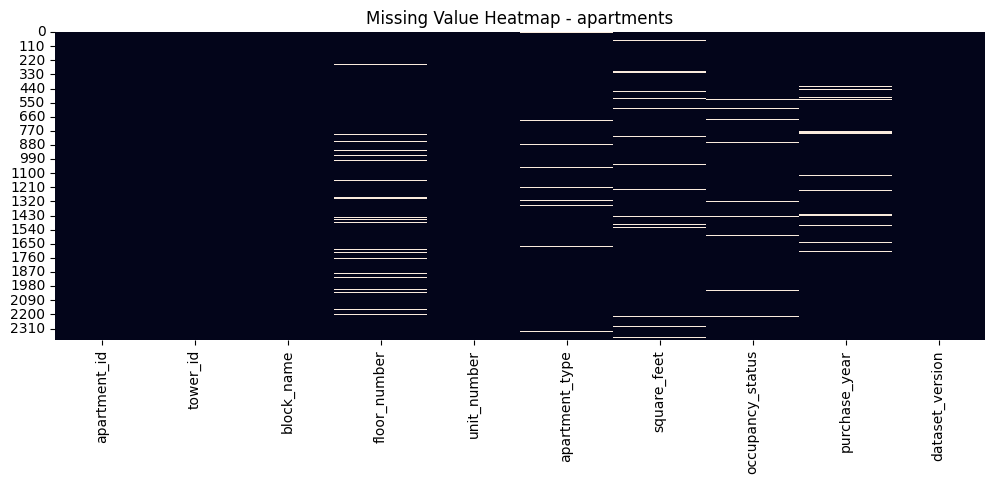

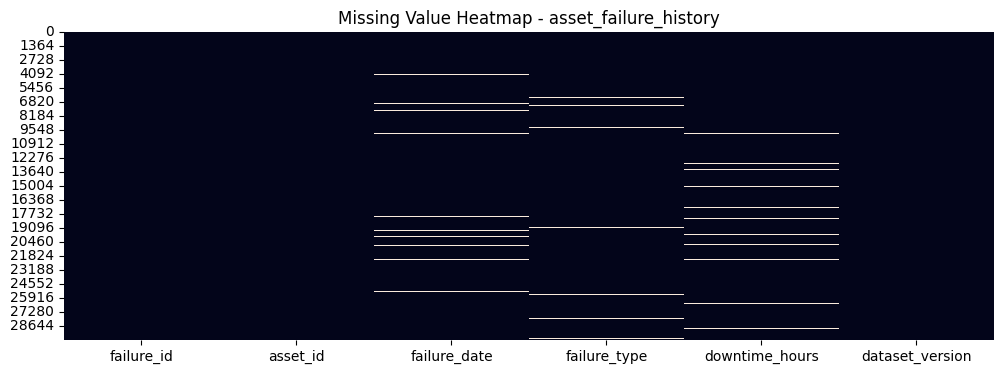

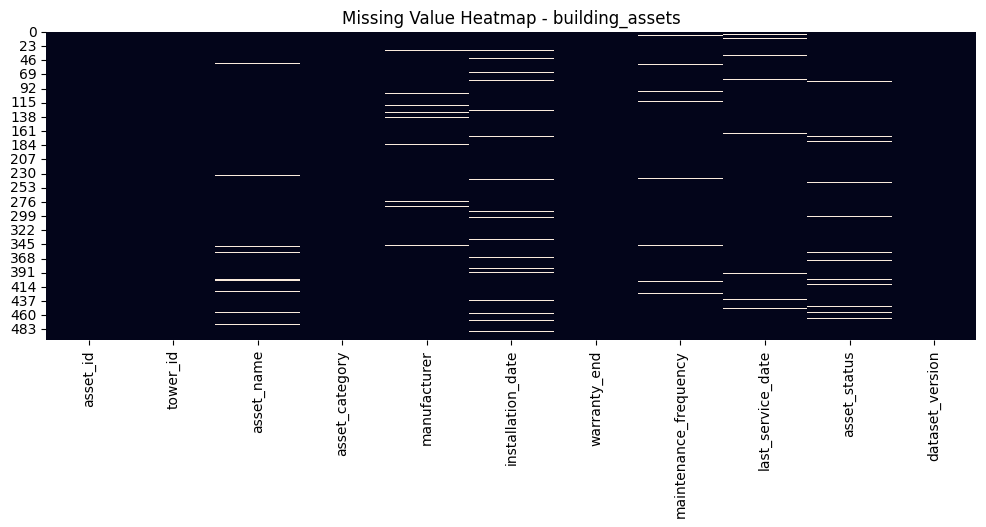

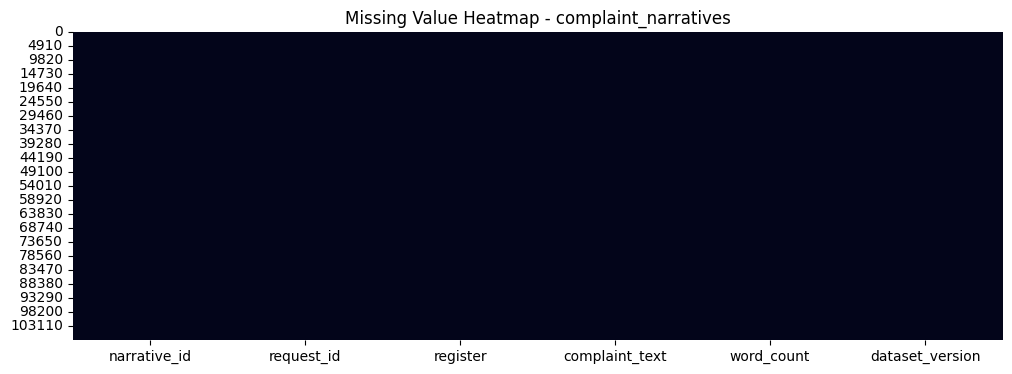

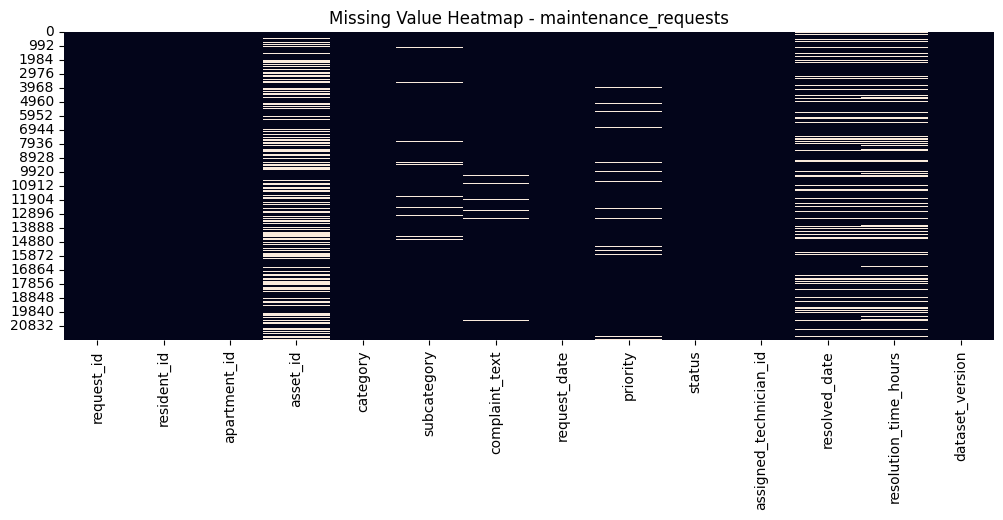

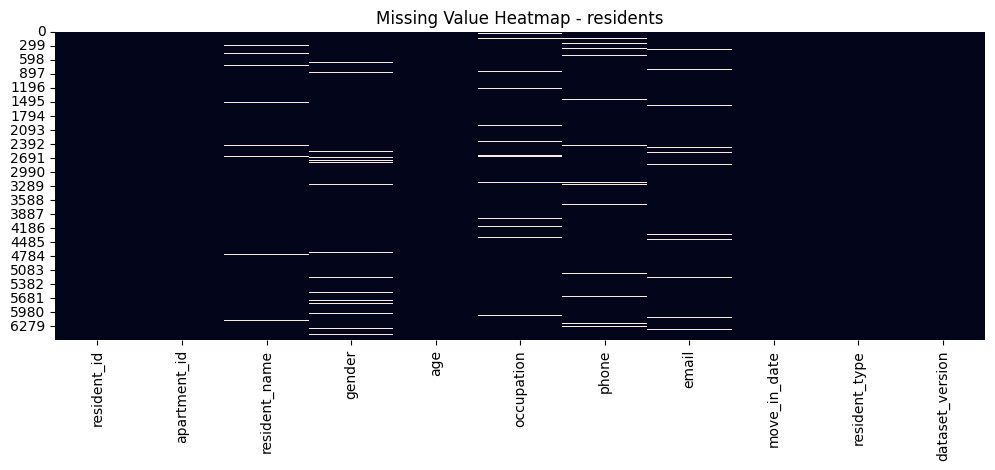

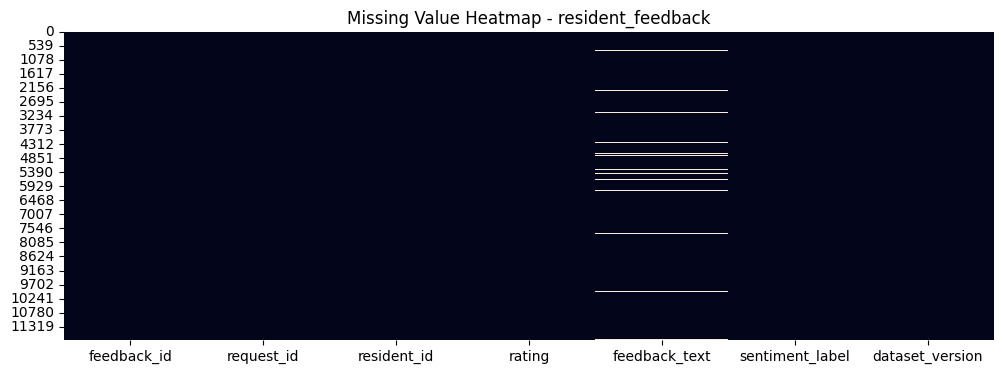

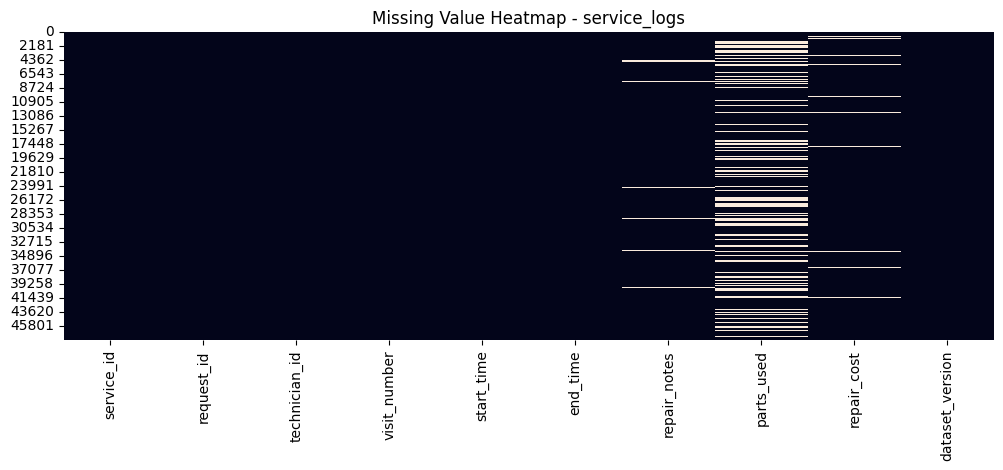

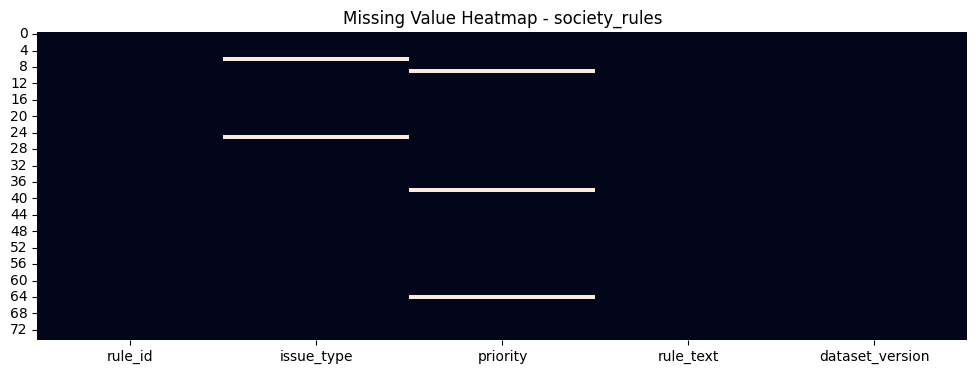

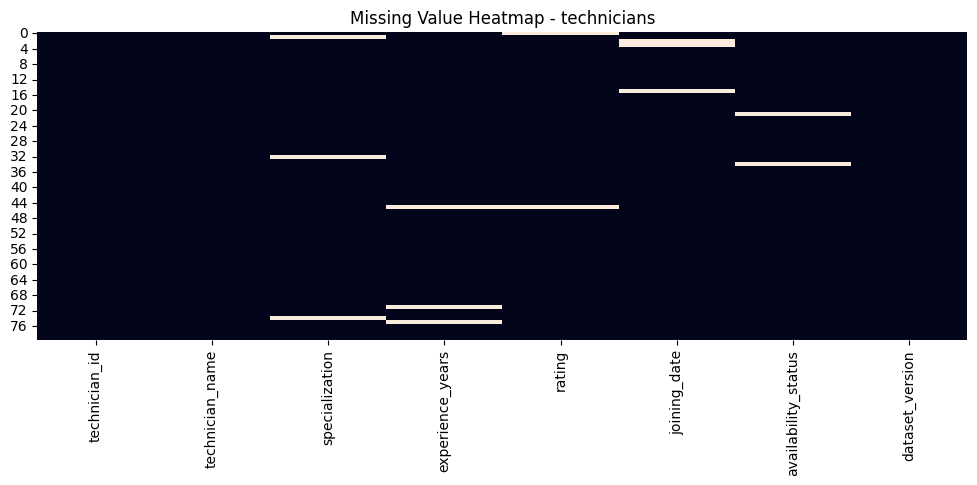

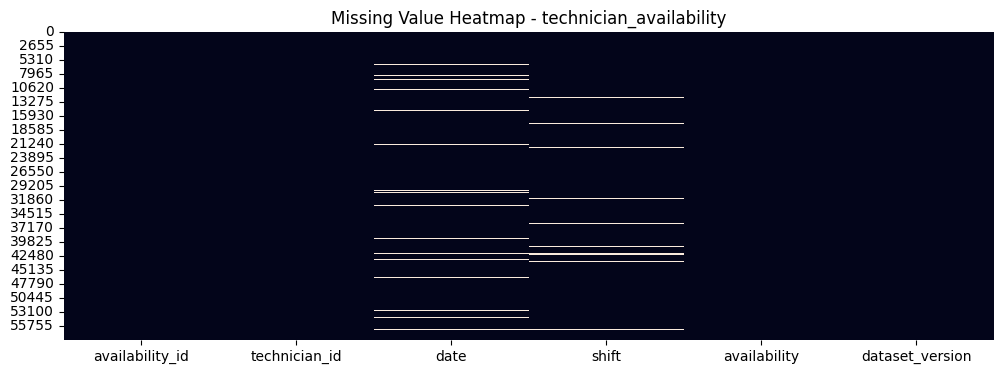

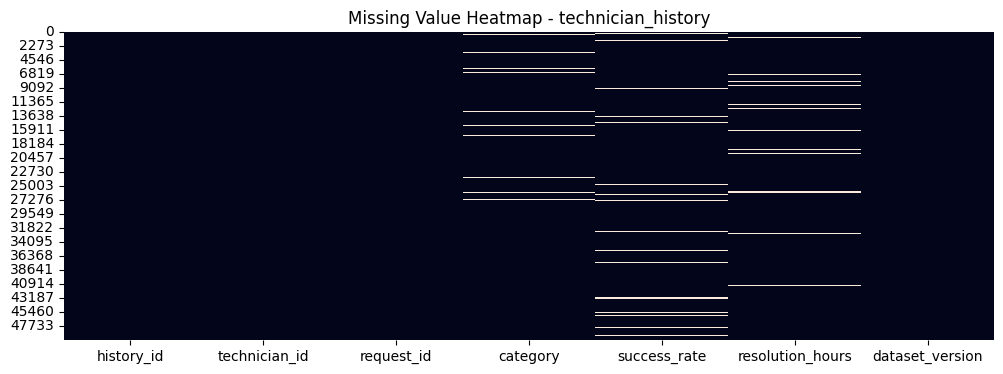

In [39]:


for name, df in tables.items():

    plt.figure(figsize=(12,4))

    sns.heatmap(

        df.isnull(),

        cbar=False

    )

    plt.title(
        f"Missing Value Heatmap - {name}"
    )

    plt.show()

<Figure size 1200x600 with 0 Axes>

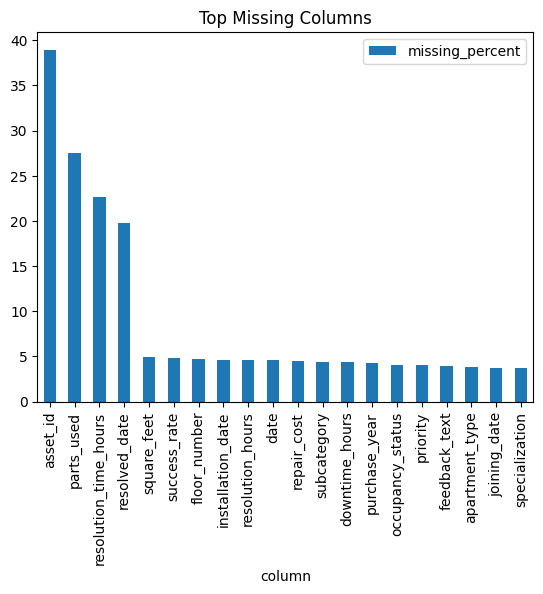

In [ ]:
plt.figure(figsize=(12,6))

missing_df.sort_values(
    "missing_percent",
    ascending=False
).head(20).plot(

    x="column",

    y="missing_percent",

    kind="bar"

)

plt.title(
    "Top Missing Columns"
)

plt.show()

In [ ]:
# Missing Value Handling
def handle_missing_values(df):

    # Drop columns >70% missing

    missing_ratio = df.isnull().mean()

    cols_to_drop = missing_ratio[
        missing_ratio > 0.70
    ].index

    df = df.drop(
        columns=cols_to_drop
    )

    # Drop rows >50% missing

    row_missing = df.isnull().mean(
        axis=1
    )

    df = df[
        row_missing <= 0.50
    ]

    # Imputation

    for col in df.columns:

        if pd.api.types.is_numeric_dtype(
            df[col]
        ):

            df[col] = df[col].fillna(
                df[col].median()
            )

        else:

            mode_value = df[col].mode()

            if len(mode_value) > 0:

                df[col] = df[col].fillna(
                    mode_value[0]
                )

            else:

                df[col] = df[col].fillna(
                    "Unknown"
                )

    return df

In [ ]:
cleaned_tables = {}

for name, df in tables.items():

    cleaned_tables[name] = handle_missing_values(
        df.copy()
    )

In [ ]:
duplicate_report = []

for name, df in cleaned_tables.items():

    duplicate_report.append({

        "table": name,

        "duplicates":

        df.duplicated().sum()

    })

duplicate_df = pd.DataFrame(
    duplicate_report
)

duplicate_df

,table,duplicates
0,apartments,0
1,asset_failure_history,0
2,building_assets,0
3,complaint_narratives,0
4,maintenance_requests,208
5,residents,65
6,resident_feedback,0
7,service_logs,475
8,society_rules,0
9,technicians,0


In [ ]:
for name, df in cleaned_tables.items():

    before = len(df)

    df = df.drop_duplicates()

    after = len(df)

    print(

        f"{name} : Removed {before-after} duplicates"

    )

    cleaned_tables[name] = df

apartments : Removed 0 duplicates
asset_failure_history : Removed 0 duplicates
building_assets : Removed 0 duplicates
complaint_narratives : Removed 0 duplicates
maintenance_requests : Removed 208 duplicates
residents : Removed 65 duplicates
resident_feedback : Removed 0 duplicates
service_logs : Removed 475 duplicates
society_rules : Removed 0 duplicates
technicians : Removed 0 duplicates
technician_availability : Removed 0 duplicates
technician_history : Removed 0 duplicates


In [ ]:
for name, df in cleaned_tables.items():

    object_cols = df.select_dtypes(
        include="object"
    ).columns

    for col in object_cols:

        df[col] = (

            df[col]

            .astype(str)

            .str.strip()

            .str.lower()

        )

    cleaned_tables[name] = df

In [ ]:
date_columns = [

    "request_date",

    "resolved_date",

    "move_in_date",

    "joining_date",

    "installation_date",

    "last_service_date"

]

for name, df in cleaned_tables.items():

    for col in date_columns:

        if col in df.columns:

            df[col] = pd.to_datetime(

                df[col],

                errors="coerce"

            )

In [ ]:
numeric_cols = []

for name, df in cleaned_tables.items():

    for col in df.select_dtypes(

        include=np.number

    ).columns:

        numeric_cols.append(

            (name,col)

        )

NameError: name 'np' is not defined

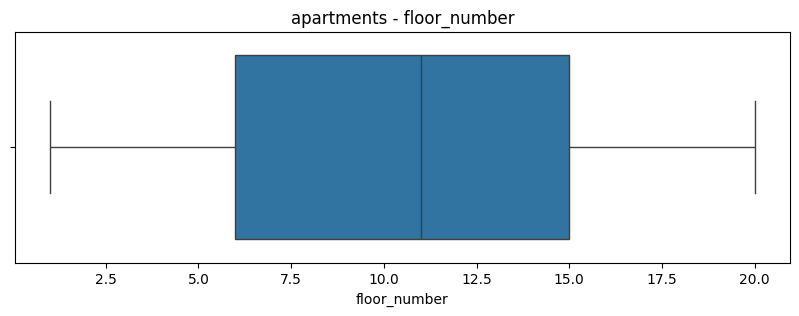

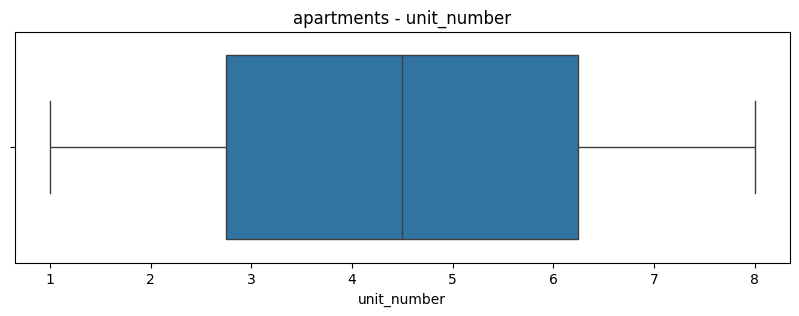

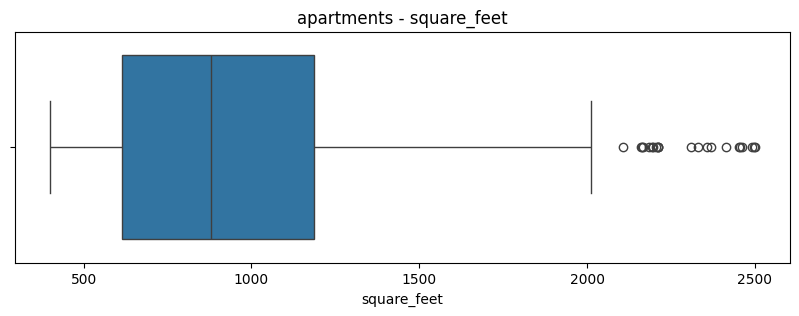

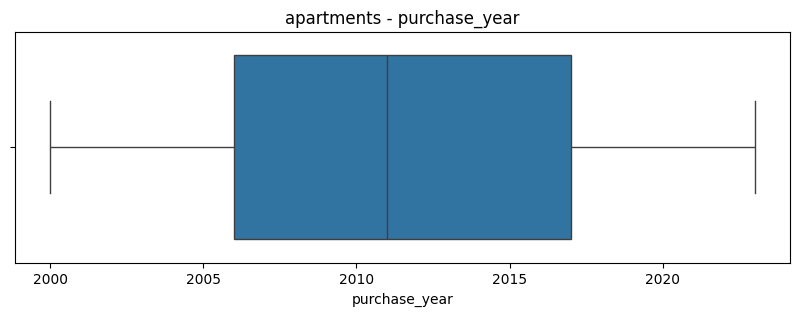

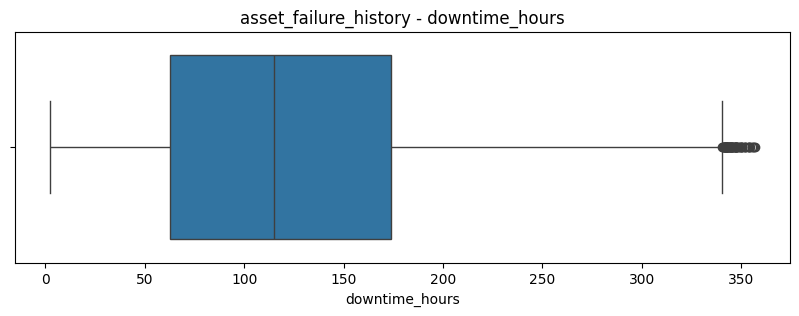

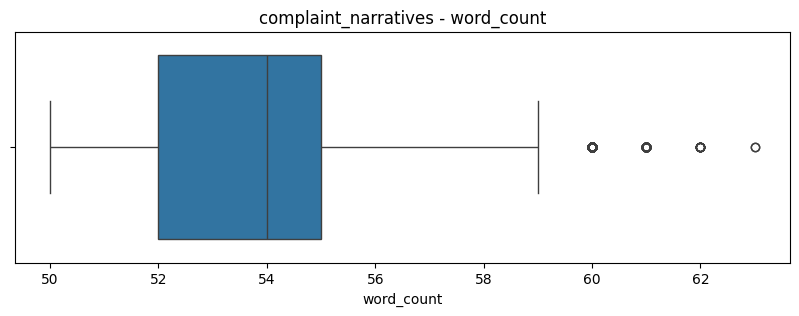

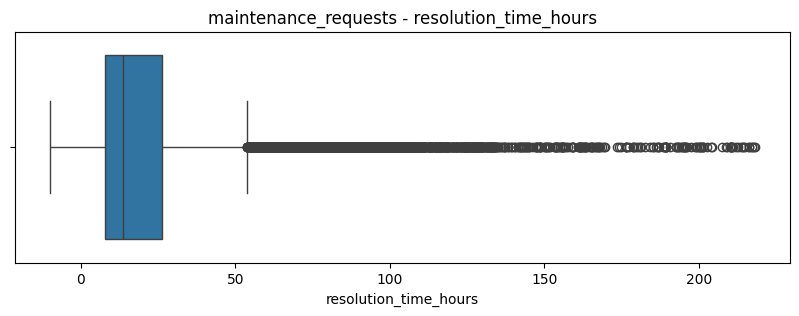

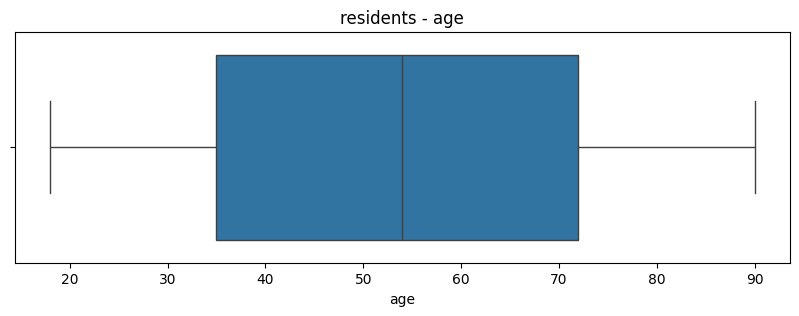

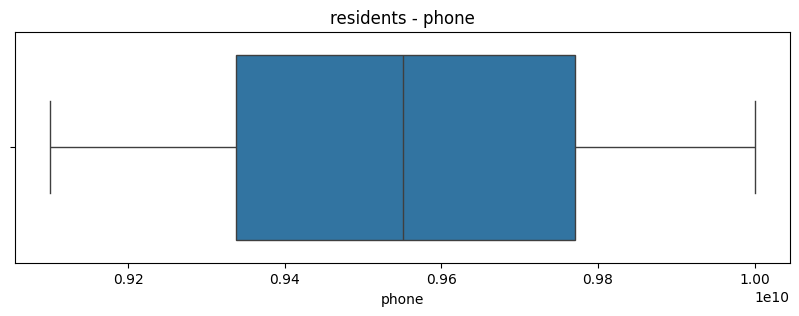

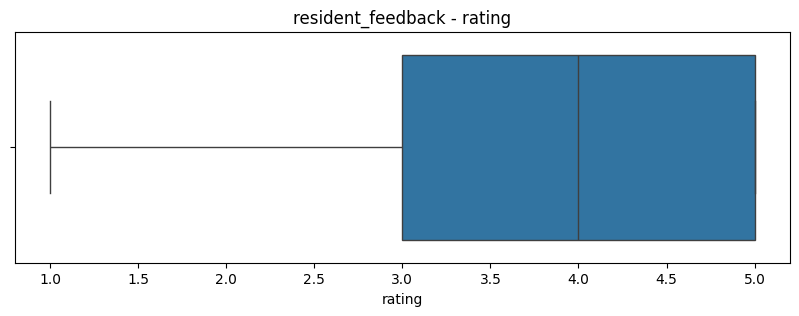

In [ ]:
for table_name, column in numeric_cols[:10]:

    plt.figure(figsize=(10,3))

    sns.boxplot(

        x=cleaned_tables[
            table_name
        ][column]

    )

    plt.title(

        f"{table_name} - {column}"

    )

    plt.show()

In [ ]:
def detect_outliers_iqr(
        df,
        column
):

    Q1 = df[column].quantile(
        0.25
    )

    Q3 = df[column].quantile(
        0.75
    )

    IQR = Q3 - Q1

    lower = Q1 - 1.5*IQR

    upper = Q3 + 1.5*IQR

    return df[

        (df[column] < lower)

        |

        (df[column] > upper)

    ]

In [ ]:
outlier_summary = []

for name, df in cleaned_tables.items():

    for col in df.select_dtypes(

        include=np.number

    ).columns:

        outliers = detect_outliers_iqr(

            df,

            col

        )

        outlier_summary.append({

            "table": name,

            "column": col,

            "outlier_count":

            len(outliers)

        })

outlier_df = pd.DataFrame(
    outlier_summary
)

outlier_df.head()

,table,column,outlier_count
0,apartments,floor_number,0
1,apartments,unit_number,0
2,apartments,square_feet,22
3,apartments,purchase_year,0
4,asset_failure_history,downtime_hours,64


In [ ]:
for name, df in cleaned_tables.items():

    numeric_cols = df.select_dtypes(

        include=np.number

    ).columns

    for col in numeric_cols:

        try:

            df[col] = winsorize(

                df[col],

                limits=[0.01,0.01]

            )

        except:

            pass

    cleaned_tables[name] = df

In [ ]:
validation_report = []

In [ ]:
if "residents" in cleaned_tables:

    residents = cleaned_tables[
        "residents"
    ]

    if "age" in residents.columns:

        invalid_age = residents[

            (residents["age"] < 0)

            |

            (residents["age"] > 120)

        ]

        validation_report.append({

            "check":"age_validation",

            "invalid_rows":

            len(invalid_age)

        })

In [ ]:
if "maintenance_requests" in cleaned_tables:

    mr = cleaned_tables[
        "maintenance_requests"
    ]

    if (
        "request_date" in mr.columns
        and
        "resolved_date" in mr.columns
    ):

        invalid_dates = mr[

            mr["resolved_date"]

            <

            mr["request_date"]

        ]

        validation_report.append({

            "check":"date_validation",

            "invalid_rows":

            len(invalid_dates)

        })

In [ ]:
validation_df = pd.DataFrame(
    validation_report
)

validation_df

,check,invalid_rows
0,age_validation,0
1,age_validation,0
2,date_validation,4447


In [ ]:
summary = []

for name, df in cleaned_tables.items():

    summary.append({

        "table": name,

        "rows": len(df),

        "columns": len(df.columns),

        "missing":

        df.isnull().sum().sum(),

        "duplicates":

        df.duplicated().sum()

    })

summary_df = pd.DataFrame(
    summary
)

summary_df

,table,rows,columns,missing,duplicates
0,apartments,2400,10,0,0
1,asset_failure_history,30000,6,0,0
2,building_assets,500,11,0,0
3,complaint_narratives,108000,6,0,0
4,maintenance_requests,21608,14,0,1
5,residents,6500,11,0,0
6,resident_feedback,11840,7,0,0
7,service_logs,47500,10,0,0
8,society_rules,75,5,0,0
9,technicians,80,8,0,0


In [ ]:
duplicate_report = []

for name, df in cleaned_tables.items():

    duplicate_report.append({

        "table": name,

        "duplicate_count": df.duplicated().sum()

    })

duplicate_df = pd.DataFrame(
    duplicate_report
)

duplicate_df

,table,duplicate_count
0,apartments,0
1,asset_failure_history,0
2,building_assets,0
3,complaint_narratives,0
4,maintenance_requests,1
5,residents,0
6,resident_feedback,0
7,service_logs,0
8,society_rules,0
9,technicians,0


In [ ]:
print(type(duplicate_df))
print(duplicate_df.head())

<class 'pandas.core.frame.DataFrame'>
                   table  duplicate_count
0             apartments                0
1  asset_failure_history                0
2        building_assets                0
3   complaint_narratives                0
4   maintenance_requests                1


In [ ]:
os.makedirs(
    "../data/cleaned",
    exist_ok=True
)

for name, df in cleaned_tables.items():

    df.to_csv(

        f"../data/cleaned/{name}.csv",

        index=False

    )

print(
    "All Cleaned Tables Saved"
)

All Cleaned Tables Saved


In [ ]:
os.makedirs(
    "../reports",
    exist_ok=True
)

missing_df.to_csv(
    "../reports/missing_report.csv",
    index=False
)

duplicate_df.to_csv(
    "../reports/duplicate_report.csv",
    index=False
)

outlier_df.to_csv(
    "../reports/outlier_report.csv",
    index=False
)

validation_df.to_csv(
    "../reports/validation_report.csv",
    index=False
)

summary_df.to_csv(
    "../reports/cleaning_summary.csv",
    index=False
)

print(
    "Reports Saved Successfully"
)

Reports Saved Successfully
